# Расчётно-графическая работа №1
**Описание выборки. Оценивание параметров.
Доверительные интервалы**

In [17]:
COLUMN = 4

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import math

from sires.SortedSires import SortedSires
from sires.SiresInfo import SiresInfo

from hist.Histogram import Histogram
from hist.IntervalRules import IntervalRules

from distrib.DistribType import DistribType
from distrib.Estimation import Estimation
from distrib.DistribDencity import DistribDencity
from distrib.EstimatedParamsPlots import EstimatedParamsPlots
from distrib.ParametricProb import ParametricProb
from distrib.ConfidenceIntervals import ConfidenceIntervals

from utils.Reader import Reader

from func.EmpericalDistribFunc import EmpericalDistribFunc

Читаем данные из файла и подготавливаем всякое


In [19]:
file = Reader("../RGR1_A-8_X1-X4.csv")
sorted_data = SortedSires(file.read_column(COLUMN-1))
sires_info = SiresInfo(sorted_data)

## 1 Первичное описание выборки

### 1.1 Вариационный ряд

In [20]:
sorted_data

Вариационный ряд
   Всего эдементов: 200
   Первые 5 элементов: 24.41, 25.28, 26.49, 26.73, 28.31
   Последние 5 элементов: 99.16, 92.67, 90.91, 88.47, 88.45

In [21]:
sires_info

Выборочные оценки:
    Среднее:                    x̄ = 57.554
    Медиана:                    x̃ =  49.655
    Размах:                     [24.4, 99.2]
    Дисперсия (смещённая):      S² =  405.118
    Дисперсия (несмещённая):    σ² =  407.154
    Ст. отклонение (смещ.):     S =  20.128
    Ст. отклонение (несмещ.):   σ =  20.178
    Квантиль 25%:               40.085
    Квантиль 50%:               49.655
    Квантиль 75%:               77.175

### 1.2 Эмпирическая функция распределения

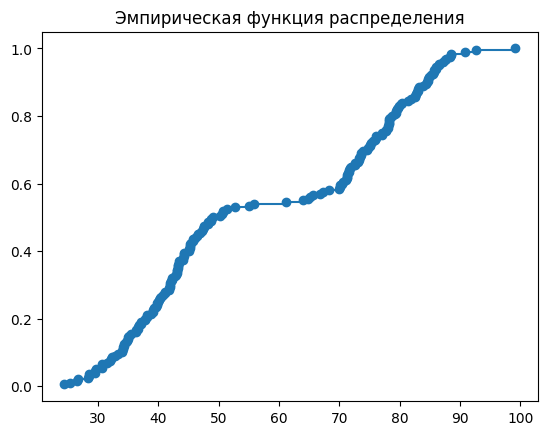

In [22]:
EmpericalDistribFunc(sorted_data).draw()
plt.show()

### 1.3 Построение гистограм

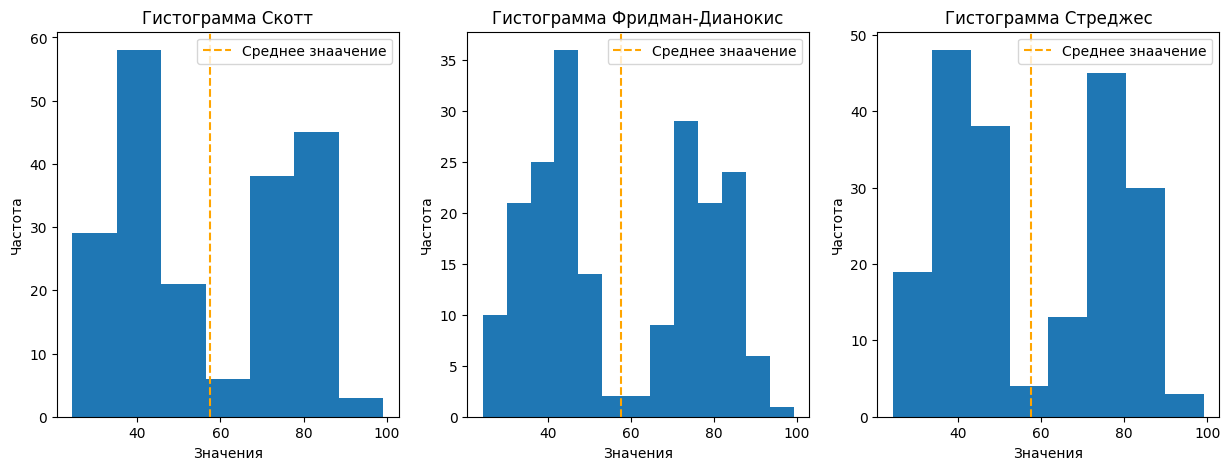

In [23]:
Histogram(sorted_data).draw_all()

### 1.4 Основные характеристики выборки

In [24]:
sires_info

Выборочные оценки:
    Среднее:                    x̄ = 57.554
    Медиана:                    x̃ =  49.655
    Размах:                     [24.4, 99.2]
    Дисперсия (смещённая):      S² =  405.118
    Дисперсия (несмещённая):    σ² =  407.154
    Ст. отклонение (смещ.):     S =  20.128
    Ст. отклонение (несмещ.):   σ =  20.178
    Квантиль 25%:               40.085
    Квантиль 50%:               49.655
    Квантиль 75%:               77.175

## 2 Разбиение на кластеры

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import random
from typing import Tuple

class KMeans:
    def __init__(self, n_clusters=2, max_iters=100):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
    
    def __call__(self, data: list[float]) -> Tuple[list[int], Tuple[list[int], list[int]]]:
        history = []

        # Инициализация центроидов случайными точками из данных
        centroids = random.choices(data, k=self.n_clusters)
        nearest = [] # заглушка для статикчека

        for _ in range(self.max_iters):
            distances = [[] for _ in range(self.n_clusters)]
            for k in range(self.n_clusters):
                for i in data:
                    distances[k].append(abs(i - centroids[k]))
            
            # Назначение каждой точки ближайшему центроиду
            nearest = [
                int(np.argmin([distances[k][i] for k in range(self.n_clusters)]))
                for i in range(len(data))
            ]
            
            # Пересчёт центроидов
            new_centroids = []
            for k in range(self.n_clusters):
                # Собираем точки, принадлежащие кластеру k
                cluster_points = [data[i] for i in range(len(data)) if nearest[i] == k]
                if cluster_points:
                    new_centroids.append(float(np.mean(cluster_points)))
                else:
                    new_centroids.append(centroids[k])  # если кластер пуст, оставляем старый центроид
            

            history.append((nearest, centroids))
            # Проверка сходимости
            if np.allclose(centroids, new_centroids):
                break
            
            centroids = new_centroids
        
        return nearest, history

labels, history  = KMeans()([i for i in sorted_data])

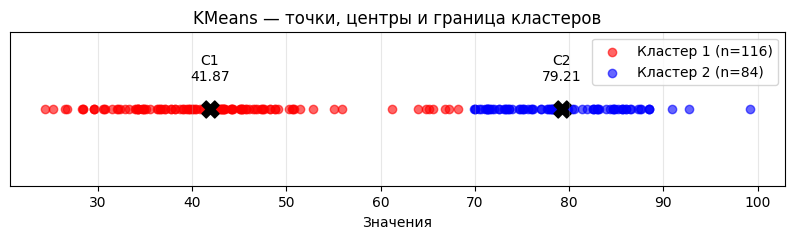

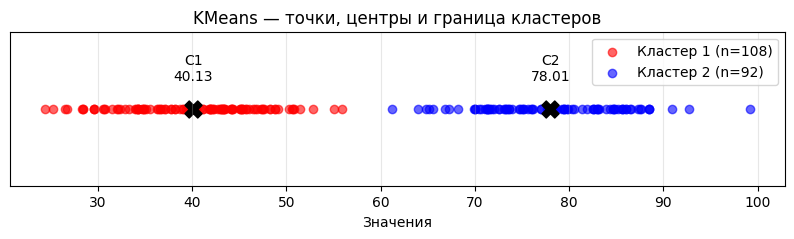

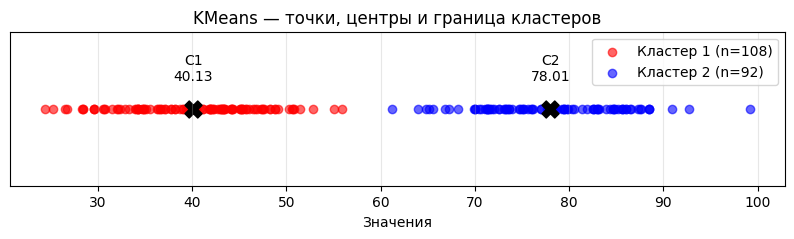

In [27]:
import numpy as np

for elem in [i[0] for i in history]:
    colors = ['red', 'blue']
    plt.figure(figsize=(10, 2))

    # считаем центры (средние по кластерам)
    centers = []
    sizes = []

    for i in range(2):
        cluster_data = [sorted_data[j] for j in range(len(sorted_data)) if elem[j] == i]
        sizes.append(len(cluster_data))
        centers.append(np.mean(cluster_data))

        # точки (1D — кладём на ось X, Y=0)
        plt.scatter(cluster_data, [0]*len(cluster_data),
                    color=colors[i],
                    label=f'Кластер {i+1} (n={len(cluster_data)})',
                    alpha=0.6)

    # центры
    for i in range(2):
        plt.scatter(centers[i], 0,
                    color='black', marker='X', s=150)
        plt.text(centers[i], 0.02,
                 f'C{i+1}\n{centers[i]:.2f}',
                 ha='center')


    plt.xlabel('Значения')
    plt.yticks([])  # убираем ось Y, т.к. данные 1D
    plt.title('KMeans — точки, центры и граница кластеров')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [12]:
[i[1] for i in history]

[[70.43, 40.13],
 [77.77290322580646, 39.98065420560748],
 [78.01054347826087, 40.12814814814815]]